# Transformer Sentiment Analysis

## 1. Setup & Configs

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no CUDA")
print(torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else "")

False
no CUDA



*Compute Environment*

No Cuda device on this local machine. Training runs on CPU.

Fine-tuning will use a subsample of the training data.

The test set stays the full split. 

In [2]:
import os
import joblib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, average_precision_score, f1_score, accuracy_score

import tqdm



In [3]:
MODEL_CKPT = 'distilbert-base-uncased'
RANDOM_STATE = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MAX_LENGTH = None
N_TRAIN = None
N_SPLITS = 5

# Paths
DATA_PATH    = "../data/processed_data/reviews_clean_v2.parquet"
BASELINE_DIR = "../models/sentiment"              # Notebook 04 artifacts
MODEL_DIR    = "../models/transformer_sentiment"  # this notebook

os.makedirs(MODEL_DIR, exist_ok=True)

# CPU threading
torch.set_num_threads(os.cpu_count())

## 2. Load Data & restore split

### 2.1 Load reviews

In [4]:
# old = pd.read_parquet('../data/processed_data/reviews_clean.parquet')
# new = pd.read_parquet('../data/processed_data/reviews_clean_v2.parquet')

# print(new['review_clean'].equals(old['review_clean']))

In [5]:
data = pd.read_parquet(DATA_PATH)

print(data.shape)

(406781, 11)


In [6]:
data.head()

,funny,helpful,hour_played,is_early_access_review,review,title,label,review_clean,language,word_count,is_duplicate
0,2.0,4,578,False,&gt Played as German Reich&gt Declare war on B...,Expansion - Hearts of Iron IV: Man the Guns,1,> played as german reich> declare war on belgi...,EN,31,False
1,0.0,0,184,False,yes.,Expansion - Hearts of Iron IV: Man the Guns,1,yes.,EN,1,False
2,0.0,0,892,False,Very good game although a bit overpriced in my...,Expansion - Hearts of Iron IV: Man the Guns,1,very good game although a bit overpriced in my...,EN,29,False
3,126.0,1086,676,False,Out of all the reviews I wrote This one is pro...,Dead by Daylight,1,out of all the reviews i wrote this one is pro...,EN,419,False
4,85.0,2139,612,False,Disclaimer I survivor main. I play games for f...,Dead by Daylight,1,disclaimer i survivor main. i play games for f...,EN,273,False


### 2.2 Rebuild group_id and split

In [7]:
from sklearn.model_selection import StratifiedGroupKFold

data['group_id'] = pd.factorize(data['review_clean'])[0]

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(
    sgkf.split(data['review_clean'], data['label'], groups=data['group_id'])
)

train = data.iloc[train_idx].reset_index(drop=True)
test  = data.iloc[test_idx].reset_index(drop=True)

print(f'Train: {len(train):,}')
print(f'Test:  {len(test):,}')

Train: 325,425
Test:  81,356


In [8]:
# The Notebook 04 test set had 81,356 rows. Same number -> same split.

assert len(test) == 81_356, f'Split mismatch: got {len(test):,}'
print('Split matches Notebook 04.')

Split matches Notebook 04.


## 3. Baseline Recap

### 3.1 Load artifacts

In [9]:
vect_baseline = joblib.load(os.path.join(BASELINE_DIR, 'sentiment_tfidf_vectorizer.joblib'))
logreg_baseline = joblib.load(os.path.join(BASELINE_DIR, 'logreg_sentiment.joblib'))

### 3.2 Predict on the restored test set

In [10]:
X_test = vect_baseline.transform(test['review_clean'])

y_test = test['label']

In [11]:
y_pred_baseline = logreg_baseline.predict(X_test)
y_proba_baseline = logreg_baseline.predict_proba(X_test)[:, 1]

pr_auc_neg_baseline = average_precision_score(1 - y_test, 1 - y_proba_baseline) # negative class

print(f'PR-AUC (negative class): {pr_auc_neg_baseline:.3f}')
print(classification_report(y_test, y_pred_baseline, digits = 3))

PR-AUC (negative class): 0.894
              precision    recall  f1-score   support

           0      0.776     0.879     0.824     24860
           1      0.944     0.888     0.915     56496

    accuracy                          0.885     81356
   macro avg      0.860     0.884     0.870     81356
weighted avg      0.892     0.885     0.887     81356



## 4. Tokenization


### 4.1 Tokenizer

In [12]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

print('Vocab size:', tokenizer.vocab_size)

Vocab size: 30522


In [13]:
sample_txt = test['review_clean'].iloc[10]

print('Sample Text:', sample_txt[:150])
print('Encoded Text', tokenizer(sample_txt))
print('Tokenized Text:', tokenizer.tokenize(sample_txt))

Sample Text: absolutely love it!!!!!
Encoded Text {'input_ids': [101, 7078, 2293, 2009, 999, 999, 999, 999, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
Tokenized Text: ['absolutely', 'love', 'it', '!', '!', '!', '!', '!']


### 4.2 Vocab Coverage

In [14]:
for w in ["won't", "don't", "not good", "unplayable", "refund", "gamebreaking"]:
    print(f'{w!r:15} -> {tokenizer.tokenize(w)}')

"won't"         -> ['won', "'", 't']
"don't"         -> ['don', "'", 't']
'not good'      -> ['not', 'good']
'unplayable'    -> ['un', '##play', '##able']
'refund'        -> ['ref', '##und']
'gamebreaking'  -> ['game', '##break', '##ing']


The tokenizer splits almost everything:

| Input | WordPiece output |
|---|---|
| `won't` | `won`, `'`, `t` |
| `don't` | `don`, `'`, `t` |
| `unplayable` | `un`, `##play`, `##able` |
| `refund` | `ref`, `##und` |
| `gamebreaking` | `game`, `##break`, `##ing` |

In Notebook 04 this would have been a problem. TF-IDF treats every token as an
independent feature, so the `won` from `won't` lands in the same column as the
`won` from "I won the match". Order and context are gone. The custom
`token_pattern` was the only defense.

DistilBERT keeps the sequence. Self-attention reads `won`, `'`, `t` together,
so the vector for `won` in `won't recommend` differs from the vector for `won`
in `won the match`. Splitting the word costs nothing because the model puts the
pieces back together.

The `un` + `##play` + `##able` split is a gain, not a loss. The model sees the
negating prefix as a unit and can carry it over to words it has never
encountered. This is how a 30k vocabulary covers unbounded text, while our
TF-IDF baseline needed 259,426 features and still went blind on anything
outside them.

**Two open threads from 04 close here.** The custom `token_pattern` has no
counterpart in this notebook: the tokenizer ships with the pretrained model and
we do not touch it. Contraction expansion (`won't` to `will not`) would fix a
problem DistilBERT does not have.

**One consequence now.** Words expand into several tokens, `refund` into two.
Token counts run higher than word counts, so the `word_count` column from 02
cannot tell us what `MAX_LENGTH` to use. We have to tokenize and measure.

## 5. Sequence Length Analysis

### 5.1 Token Length Distribution

In [15]:
samples = train.sample(10_000, random_state= RANDOM_STATE)

len_clean_review = [len(x) for x in tokenizer(samples['review_clean'].tolist())['input_ids']]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (633 > 512). Running this sequence through the model will result in indexing errors


In [16]:
percentiles = [50, 90, 95, 99]
values = np.percentile(len_clean_review, percentiles)

print(f'Token lengths (review_clean, n = {len(len_clean_review):,})\n')
for p, v in zip(percentiles, values):
    print(f'  {p:>2}th percentile: {v:>6.0f} tokens')
print(f'\n  max:            {max(len_clean_review):>6} tokens')
print(f'  mean:           {np.mean(len_clean_review):>6.1f} tokens')

Token lengths (review_clean, n = 10,000)

  50th percentile:     22 tokens
  90th percentile:    130 tokens
  95th percentile:    209 tokens
  99th percentile:    507 tokens

  max:              1822 tokens
  mean:             55.1 tokens


*Input variant*

We feed the model `review_clean`. Two properties matter for a transformer:
punctuation and word order survive the cleaning, so the model keeps the signals
its pretraining taught it to read. The cleaning also repairs broken HTML
artifacts like &gt, which never occur in natural text and would only add noise.

In [17]:
MAX_LENGTH = 256

# 95% of reviews fit in 209 tokens; the 99th percentile jumps to 507.#
# Attention cost grows with the square of the length, so 512 would cost four times what 256 does to capture the last 4%

## 6. Data Preparation

### 6.1 Subsample Training Set

In [18]:
from sklearn.model_selection import train_test_split

train_sub, _ = train_test_split(
    train, train_size = 25000, stratify = train['label'], random_state = RANDOM_STATE
)

print(train_sub['label'].value_counts(normalize = True).round(3))

label
1    0.694
0    0.306
Name: proportion, dtype: float64


In [19]:
y_train = train_sub['label'].values
y_test  = test['label'].values

In [20]:
train_sub[['review_clean', 'label']].to_parquet('colab_train.parquet', index=False)
test[['review_clean', 'label']].to_parquet('colab_test.parquet', index=False)

### 6.2 HuggingFace Dataset Object

In [21]:
# from datasets import Dataset

# cols = ['review_clean', 'label']

# train_ds = Dataset.from_pandas(train_sub[cols], preserve_index = False)
# test_ds = Dataset.from_pandas(test[cols], preserve_index = False)

# train_ds = train_ds.rename_column('label', 'labels')
# test_ds = test_ds.rename_column('label', 'labels')

In [22]:
# print('Train Set:\n', train_ds)
# print()
# print('Test Set:\n', test_ds)

### 6.3 Tokenize

In [23]:
# def tokenize(batch):
#     return tokenizer(
#         batch['review_clean'],
#         truncation = True,
#         MAX_LENGTH = MAX_LENGTH
#     )

In [24]:
# train_tok = train_ds.map(tokenize, batched = True)
# test_tok = test_ds.map(tokenize, batched = True)

In [25]:
print(train_tok)

NameError: name 'train_tok' is not defined

## 7. Frozen Embedding as Features


### 7.1 Extract Embeddings

In [26]:
from transformers import AutoModel

# model = AutoModel.from_pretrained(MODEL_CKPT).to(DEVICE)
# model.eval() #inference model: disables dropout etc

# def extract_features(texts, batch_size = 32):
#     features = []
#     for i in tqdm.tqdm(range(0, len(texts), batch_size)):
#         batch_txt = texts[i : i + batch_size]

#         # Tokenize this batch directly to tensors
#         inputs = tokenizer(
#             batch_txt,
#             truncation = True,
#             max_length = MAX_LENGTH,
#             padding = True,
#             return_tensors = 'pt',
#         ).to(DEVICE)


#         # Forward path without building backprob graph
#         # No training
#         with torch.no_grad():
#             outputs = model(**inputs)

#         # Last hidden state shape[batch, sequence, 768]
#         cls = outputs.last_hidden_state[:, 0]

#         # Move to cpu and numpy
#         features.append(cls.cpu().numpy())
#     return np.vstack(features)

In [ ]:
# X_train_emb = extract_features(train_sub['review_clean'].tolist())
# X_test_emb  = extract_features(test['review_clean'].tolist())

In [ ]:
# EMB_TRAIN_PATH = os.path.join(MODEL_DIR, 'emb_train.npy')
# EMB_TEST_PATH  = os.path.join(MODEL_DIR, 'emb_test.npy')

# if os.path.exists(EMB_TRAIN_PATH):
#     X_train_emb = np.load(EMB_TRAIN_PATH)
#     X_test_emb  = np.load(EMB_TEST_PATH)
#     print('Loaded cached embeddings')
# else:
#     X_train_emb = extract_features(train_sub['review_clean'].tolist())
#     X_test_emb  = extract_features(test['review_clean'].tolist())
#     np.save(EMB_TRAIN_PATH, X_train_emb)
#     np.save(EMB_TEST_PATH,  X_test_emb)
#     print('Extracted and cached embeddings')

# print(f'Train: {X_train_emb.shape}')   # (25000, 768)
# print(f'Test:  {X_test_emb.shape}')    # (81356, 768)

*Forward passes run on Colab*

DistilBERT forward passes crashed the local kernel: on CPU, extracting embeddings for the full 81k test set

Both forward-pass stages (embedding extraction & fine-tuning) run on Colab with T4 GPU. The artifacts come back here.
Everything else stays local.

In [27]:
# Embeddings were extracted on Colab (GPU). Load them here.

X_train_emb = np.load('../data/colab_data/X_train_emb.npy')
X_test_emb  = np.load('../data/colab_data/X_test_emb.npy')

y_train = train_sub['label'].values
y_test  = test['label'].values

print(X_train_emb.shape, X_test_emb.shape)

(25000, 768) (81356, 768)


### 7.2 Train LogReg on Embeddings

In [28]:
from sklearn.linear_model import LogisticRegression

clf_emb = LogisticRegression(
    class_weight = 'balanced',
    max_iter = 1000,
    random_state = RANDOM_STATE
)

clf_emb.fit(X_train_emb, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### 7.3 Eval


In [29]:
y_pred_emb = clf_emb.predict(X_test_emb)
y_proba_emb = clf_emb.predict_proba(X_test_emb)[:, 1]

print('Frozen DistilBERT + LogReg')
print(f'macro-F1:           {f1_score(y_test, y_pred_emb, average="macro"):.3f}')
print(f'PR-AUC (neg class): {average_precision_score(1 - y_test, 1 - y_proba_emb):.3f}')
print(classification_report(y_test, y_pred_emb, digits=3))

Frozen DistilBERT + LogReg
macro-F1:           0.817
PR-AUC (neg class): 0.824
              precision    recall  f1-score   support

           0      0.688     0.843     0.758     24860
           1      0.923     0.832     0.875     56496

    accuracy                          0.835     81356
   macro avg      0.806     0.838     0.817     81356
weighted avg      0.852     0.835     0.839     81356



Frozen Embeddings lose to the baseline: macro-F1 0.817 against 0.870.


The gap sits in the negative class. Precision drops from 0.776 to 0.6888, so the frozen model raises more false alarms on 'Not Recommended'. 
The pretrained [CLS] vector encodes generic language, not sentiment. DistilBERT learned it by predicting masked words and a plain LogReg cannot recover a sentiment signal the vector never carried.

## 8. Fine-Tuning DistilBERT

In [ ]:
# from transformers import AutoModelForSequenceClassification

# num_labels = 2
# model = AutoModelForSequenceClassification.from_pretrained(MODEL_CKPT, num_labels = num_labels,
#                                                            id2label = {0: 'Not Recommended', 1: 'Recommended'},
#                                                            label2id = {'Not Recommended': 0, 'Recommended': 1})

In [ ]:
# def compute_metrics(pred):
#     labels = pred.label_ids
#     preds = pred.predictions.argmax(-1)
#     f1 = f1_score(labels, preds, average = 'macro')
#     acc = accuracy_score(labels, preds)
#     return {'accuracy': acc, 'f1': f1}

In [ ]:
# from datasets import Dataset

# train_ds = Dataset.from_pandas(train_df[['review_clean', 'label']], preserve_index=False)
# test_ds  = Dataset.from_pandas(test_df[['review_clean', 'label']],  preserve_index=False)

# train_ds = train_ds.rename_column('label', 'labels')
# test_ds  = test_ds.rename_column('label', 'labels')

# def tokenize(batch):
#     return tokenizer(batch['review_clean'], truncation=True, max_length=MAX_LENGTH)

# train_ds = train_ds.map(tokenize, batched=True)
# test_ds  = test_ds.map(tokenize,  batched=True)

In [ ]:
# from transformers import TrainingArguments, Trainer

# training_args = TrainingArguments(
#     output_dir = f'{MODEL_CKPT}-finetuned-reviews',
#     num_train_epochs = 4,
#     learning_rate = 2e-5,
#     per_device_train_batch_size = 32,
#     per_device_eval_batch_size = 32,
#     eval_strategy = 'epoch',
#     disable_tqdm = False,
# )

# trainer = Trainer(
#     model = model,
#     args = training_args,
#     train_dataset = train_ds,
#     eval_dataset = test_ds,
#     processing_class = tokenizer,
#     data_collator = data_collator,
#     compute_metrics = compute_metrics,
# )

# trainer.train()

In [ ]:
# preds = trainer.predict(test_ds)
# y_proba_bert = torch.softmax(torch.tensor(preds.predictions), dim = 1)[:, 1].numpy()
# y_pred_bert = y_proba_bert.predictions.artmax(-1)

*Fine-tuning ran on Colab*

Fine-tuning DistilBERT needs GPU. The forward and backward passes over 25k reviews are far too slow on CPU.
The training ran on Colab with a T4. 
The cells above are the exact Colab cells, kept here for the record but do not run locally. 

## 9. Evaluation on shared Test Set

### 9.1 Load fine-tuned predictions

In [30]:
y_pred_bert  = np.load('../data/colab_data/y_pred_bert.npy')
y_proba_bert = np.load('../data/colab_data/y_proba_bert.npy')

print(y_pred_bert.shape, y_proba_bert.shape)

(81356,) (81356,)


### 9.2 Metrics


In [31]:
def scores(name, y_pred, y_proba):
    return {
        'model': name,
        'macro-f1': f1_score(y_test, y_pred, average = 'macro'),
        'pr_auc_neg': average_precision_score(1 - y_test, 1 - y_proba)
    }

results = pd.DataFrame([
    scores('TF-IDF + LogReg (04)',      y_pred_baseline, y_proba_baseline),
    scores('Frozen DistilBERT + LogReg', y_pred_emb,      y_proba_emb),
    scores('Fine-tuned DistilBERT',      y_pred_bert,     y_proba_bert),
])

print(results.round(3).to_string(index = False))

                     model  macro-f1  pr_auc_neg
      TF-IDF + LogReg (04)     0.870       0.894
Frozen DistilBERT + LogReg     0.817       0.824
     Fine-tuned DistilBERT     0.868       0.894


### 9.3 Confusion matrices

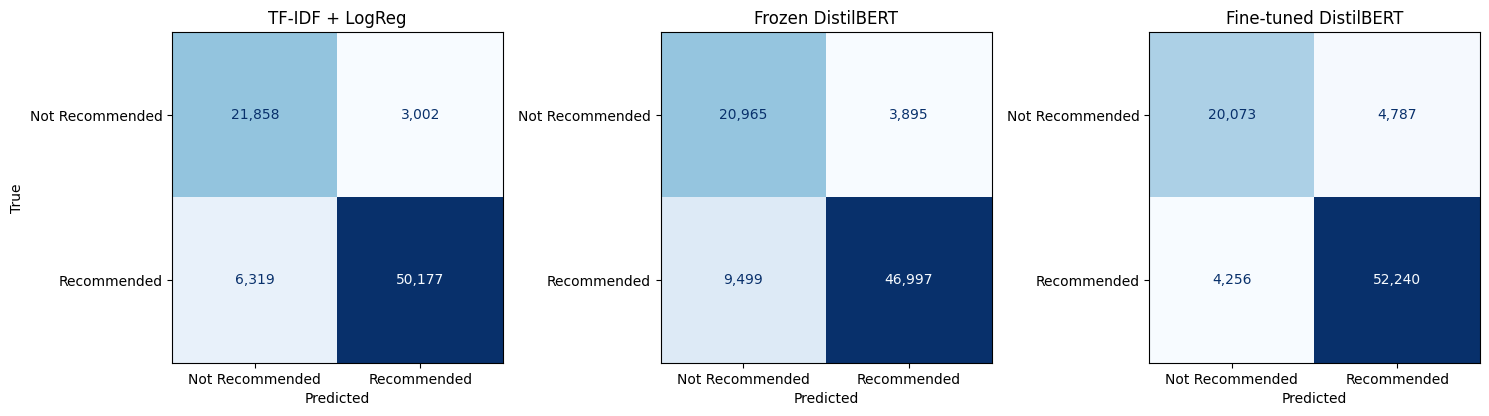

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models = [
    ('TF-IDF + LogReg',        y_pred_baseline),
    ('Frozen DistilBERT',      y_pred_emb),
    ('Fine-tuned DistilBERT',  y_pred_bert),
]

labels = ['Not Recommended', 'Recommended']   # 0, 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True' if ax is axes[0] else '')

plt.tight_layout()
plt.show()

The three models share almost the same macro-F1, but the confusion matrices show
they make opposite errors.

| Model | Not Rec → false positive | Rec → false negative |
|---|---|---|
| TF-IDF + LogReg | 3,002 | 6,319 |
| Frozen DistilBERT | 3,895 | 9,499 |
| Fine-tuned DistilBERT | 4,787 | 4,256 |

The baseline plays it safe on "Recommended": it lets few negative reviews slip
through (3,002) but misses 6,319 real recommendations. Fine-tuned DistilBERT
leans the other way — it catches almost every recommendation (4,256 missed) but
lets more negative reviews pass as positive (4,787). Same headline number, two
different behaviours.

Which one wins depends on the task. To measure satisfaction or surface
recommendations, DistilBERT's higher recall on "Recommended" helps. To triage
complaints and not miss unhappy users, the baseline's tighter grip on "Not
Recommended" helps.

The split is not fixed. Both models were compared at the default 0.5 threshold.
Lowering it makes a model flag more negatives at the cost of more false alarms.
The PR-AUC measures quality across all thresholds, and there baseline and
fine-tuned tie at 0.894. Both can be tuned to either task; they just start at
different points.

## 10. Error Analysis

### 10.1 Disagreement cases

In [33]:
# Where do baseline and fine-tuned disagree?

disagree = y_pred_baseline != y_pred_bert
print(f'{disagree.sum():,} reviews where baseline and fine-tuned disagree')

inspect = test[disagree].copy()
inspect['true']       = y_test[disagree]
inspect['baseline']   = y_pred_baseline[disagree]
inspect['bert']       = y_pred_bert[disagree]
inspect['proba_bert'] = y_proba_bert[disagree]

8,734 reviews where baseline and fine-tuned disagree


In [34]:
bert_right = inspect[inspect['bert']     == inspect['true']]
base_right = inspect[inspect['baseline'] == inspect['true']]

print(f'Fine-tuned right, baseline wrong: {len(bert_right):,}')
print(f'Baseline right, fine-tuned wrong: {len(base_right):,}')

Fine-tuned right, baseline wrong: 4,506
Baseline right, fine-tuned wrong: 4,228


In [36]:
# Confident BERT wins — sort by how sure the transformer was
confident = bert_right.copy()
confident['confidence'] = abs(confident['proba_bert'] - 0.5)
confident = confident.sort_values('confidence', ascending=False)

for _, row in confident.head(8).iterrows():
    print(f"true={row['true']} bert={row['bert']} p={row['proba_bert']:.2f}")
    print('—', row['review_clean'][:250])
    print()

true=1 bert=1 p=1.00
— the game has its charm at first you start out fresh dont know the basics and mechanincs then you get better with a time and thats where the fun really starts aaaand then the cheaters who watch throught walls teleport around you and has and aimbot.p.s

true=1 bert=1 p=1.00
— this game had many glitches in the past and was broken this was a shame cuz the game is really enjoyable. now though almost every glitch is fixed and this game is so much fun.

true=1 bert=1 p=1.00
— very good game! wonderful! very well optimized an unforgettable adventure. the mods they do not lack.who became negative the game because of the mods is a !

true=1 bert=1 p=1.00
— about a moth after launch and this game is already better than h1z1 ever was. instead of adding microtransactions there are weekly optimization updates! this is the way to go! strongly recommending this game

true=1 bert=1 p=1.00
— i was patient and did not play this game until its release on pc and i have to say it was

Baseline and fine-tuned disagree on 8,734 reviews, split almost evenly: 4,506 go to the transformer, 4,228 to the baseline. Neither model wins. Each takes its own half, which is why their macro-F1 lands the same.

The reviews where the transformer wins with full confidence (p = 100) share one shape: positive verdicts that spend most of their words on the negative:
'Charm at first *aaaand then...*' for example.

The baseline sees the negative words and calls the review instantly negative. It cannot see that the words sit inside a contrast.



### 10.2 Vocab leakage

In [37]:
mask_mod = test['review_clean'].str.contains('modding|take two|take-two', case=False, na=False)
sub = test[mask_mod].copy()
sub['true']     = y_test[mask_mod.values]
sub['baseline'] = y_pred_baseline[mask_mod.values]
sub['bert']     = y_pred_bert[mask_mod.values]

print(f'{len(sub):,} reviews mention modding / take two')
print(f"Baseline  macro-F1: {f1_score(sub['true'], sub['baseline'], average='macro'):.3f}")
print(f"Fine-tuned macro-F1: {f1_score(sub['true'], sub['bert'],     average='macro'):.3f}")

2,558 reviews mention modding / take two
Baseline  macro-F1: 0.742
Fine-tuned macro-F1: 0.810


**Conclusion**

In Notebook 04 the terms modding and take two leaked: reviews about the resolved
Take-Two modding dispute pile up negative words (banned, lawsuit, drama) while the
verdict stays positive. The baseline learned modding as a negative signal. We
documented the leak rather than removing the term, since dropping it would have
cut real signal.

On the 2,558 test reviews that mention these terms, the two models split:

| Model | macro-F1 on modding / take two reviews |
|---|---|
| Baseline | 0.742 |
| Fine-tuned | 0.810 |

Both drop below their overall score, so these are genuinely hard reviews. But the
transformer drops far less. It reads modding inside the sentence that surrounds it
instead of scoring the word on its own.

This closes the thread from 04 without a manual fix. The leak was never removed;
a context-sensitive model made the removal unnecessary. The gain is real but
partial — 0.810 is not 0.870, so the transformer softens the leakage rather than
erasing it.

## 11. Cost vs. Benefit

### Training time, inference latency, model size

In [41]:
size = os.path.getsize('../models/transformer_sentiment/distilbert_finetuned_colab/model.safetensors')
print(f'{size / 1e6:.0f} MB')

268 MB


| Dimension | TF-IDF + LogReg | Fine-tuned DistilBERT |
|---|---|---|
| Training data | ~325k | 25k |
| Training time | seconds (CPU) | ~70 min (T4 GPU) |
| Trains on CPU | yes | not feasible |
| Inference on 81k | seconds (CPU) | crashed the CPU kernel; minutes on GPU |
| Model size | a few MB | 268 MB |
| Feature engineering | token_pattern, min_df, bigrams | none |
| Needs a GPU | no | yes |

**The trade-off**

The transformer did not raise the score. Macro-F1 landed at 0.868 against the
baseline's 0.870, and PR-AUC tied at 0.894. If accuracy were the only axis, the
two are the same model.

The transformer's gain sits on three other axes. It reached that score on 25k
reviews, an eighth of the 325k the baseline trained on — transfer learning does
the rest. It needed no feature engineering: no token_pattern, no min_df sweep, no
bigram decision. And it reads context, so it wins on reviews built around a
reversal ("broken then fixed") and softens the modding leakage the baseline could
only route around.

The cost sits on the axes the baseline owns. Fine-tuning took 70 minutes on a
rented T4; the baseline trains in seconds on this laptop. The model weighs 268 MB
against a few. Inference on the full test set crashed the local kernel and had to
move to the GPU, while the baseline scores 81k reviews on CPU in seconds.

So the choice depends on what is scarce. When labeled data is limited and there
is no time for feature engineering, the transformer earns its keep. When the
pipeline has to run on CPU and answer in milliseconds, the baseline wins on equal
accuracy at a fraction of the cost. For this project — a laptop, no GPU, hundreds
of thousands of reviews to score — the baseline is the model I would ship, and
the transformer is the one that taught me why.

## 12. Conclusions

Three models on the same task and the same test set:

| Model | macro-F1 | PR-AUC neg |
|---|---|---|
| TF-IDF + LogReg | 0.870 | 0.894 |
| Frozen DistilBERT | 0.817 | 0.824 |
| Fine-tuned DistilBERT | 0.868 | 0.894 |

Frozen embeddings lost, fine-tuning tied the baseline. So the architecture alone
did not help; adapting it to the domain did.

What a transformer buys here is not a higher score. It matched the baseline on an
eighth of the training data, needed no feature engineering, and read context the
baseline could not — reversals and the modding leakage from Notebook 04. What it
costs is a GPU, 70 minutes of training, and a 268 MB model that cannot run
inference on this CPU.

For a CPU-bound pipeline scoring hundreds of thousands of reviews, TF-IDF + LogReg
stays the model to ship. The transformer answered the question the project set out
to ask.